In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision as vision

import matplotlib.pyplot as plt

import numpy as np

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from helper_functions import *

# print(f"Torch: version {torch.__version__}")
# device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_device("cpu")
# print(f"Device: {device}")
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [3]:
# Input and Outputs
# Input: 244 * 244 * 3 
# output: classification

# torchvision.datasets example datasa
# torchvision.models example and standard vision models

# torch.utils.data.Dataset : dataset class for custom datasets

In [4]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)

2.7.1
0.22.1


In [5]:
# getting the data
# MORE: lets try to use EMNIST to find digits
import kagglehub as kg
print(kg.__version__)

# Download latest version
path = kg.dataset_download("hojjatk/mnist-dataset")

print("Path to dataset files:", path)

# We are going to use fashion

0.3.12
Path to dataset files: /Users/giovannirasera/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1


In [6]:
# Setting training data
train_data = datasets.FashionMNIST(
    root="dataFashion",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None # How to transform the labels,
)
test_data = datasets.FashionMNIST(
    root="dataFashion",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None 
)

In [7]:
len(train_data), len(test_data)

(60000, 10000)

In [8]:
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [9]:
print(image.shape) # we are using color channel first
print(label)
print(train_data.class_to_idx)
train_data.targets
class_names = train_data.classes
print(class_names)

torch.Size([1, 28, 28])
9
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

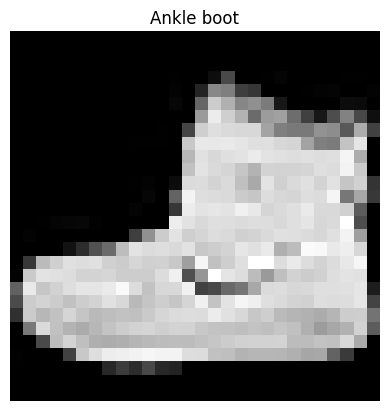

In [10]:
# plt.imshow(image) cannot use this because plt uses color channel last

plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)

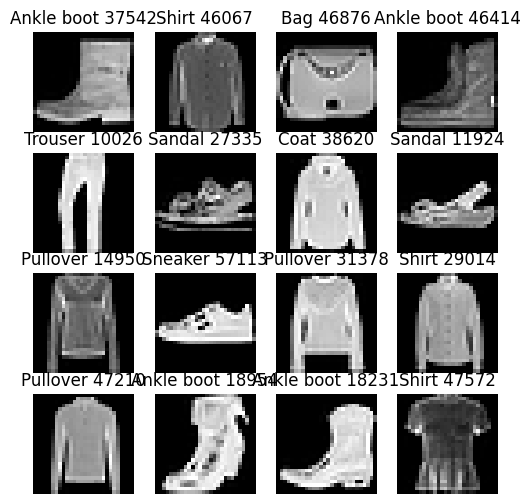

In [11]:
# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(6, 6))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i) # i is the index
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label] + f" {random_idx}")
    plt.axis(False)


In [12]:
# Prepare dataloader
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: dataFashion
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: dataFashion
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [13]:
# DataLoader is trasforming data into a iterable and into batches
# Hardware cannot store all images into ram so we need to device the data

from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=True)
print(train_dataloader)
# print(test_dataloader)

In [14]:
print(f"Len of trian data: {len(train_dataloader)} of batchsize: {BATCH_SIZE}")

Len of trian data: 1875 of batchsize: 32


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

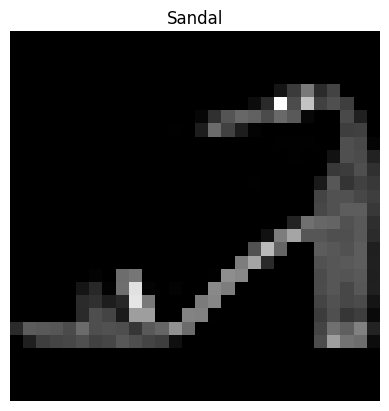

In [15]:
# whats inside training dataloader
train_features_batch, train_label_batch = next(iter(train_dataloader))
test_features_batch, test_label_betch = next(iter(test_dataloader))
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_label_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)


In [16]:
# Crate a baseline model
# to pass from conv to a nn we need to use Flatten
x = train_features_batch[0]
x.shape

torch.Size([1, 28, 28])

In [17]:
flatted = nn.Flatten()(x)
flatted # One bit vector of features

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0039, 0.0039, 0.0000, 0.0000, 0.0078, 0.0078,
         0.0000, 0.0000, 0.0039, 0.0078, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.2863, 0.0000, 0.0

In [18]:
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)

inf = (len(nn.Flatten()(img).squeeze()))
model = FashionMNISTModelV0(inf, 10, len(class_names))

In [19]:
model.to("cpu")

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [20]:
dummy_x = torch.rand([ 1, 28, 28])
model(dummy_x).shape

torch.Size([1, 10])

In [21]:
model.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[-0.0165, -0.0101, -0.0215,  ...,  0.0052,  0.0173,  0.0309],
                      [-0.0218, -0.0176,  0.0069,  ..., -0.0169,  0.0213,  0.0087],
                      [-0.0238,  0.0124, -0.0214,  ..., -0.0096,  0.0006, -0.0324],
                      ...,
                      [ 0.0312,  0.0269,  0.0015,  ...,  0.0082,  0.0330,  0.0051],
                      [ 0.0048, -0.0134, -0.0141,  ..., -0.0345,  0.0140,  0.0278],
                      [ 0.0035, -0.0279,  0.0321,  ..., -0.0084,  0.0227, -0.0054]])),
             ('layer_stack.1.bias',
              tensor([-0.0284, -0.0354, -0.0013,  0.0105, -0.0211,  0.0281,  0.0169,  0.0215,
                       0.0165, -0.0344])),
             ('layer_stack.2.weight',
              tensor([[-0.0580,  0.1643,  0.1565, -0.2877, -0.1792,  0.2305, -0.2618,  0.2397,
                       -0.0610,  0.0232],
                      [ 0.1542,  0.0851, -0.2027,  0.1030, -0.2715, -0.1596, -0.

In [48]:
# Setting up optimizer and loss functions
# Multiflass data will be use crossentropyloss
# Optimizer: SGD
# Evaluation metrics will be accuracy

def flatten(y_, n_classes):
    y_train_blob = torch.zeros(len(y_))
    for i in range(len(y_train_blob)):
        for c in range(n_classes):
            if int(y_[i][c].item()) == 1:
                y_train_blob[i] = c
    return y_train_blob

# Calculate accuracy - out of 100 what percent the model gets right
def accuracy_fn(y_test, preds, n_classes = 4):
    y_test_blob = flatten(y_test, n_classes)
    peds_train_blob = flatten(preds, n_classes)
    correct = torch.sum(torch.eq(y_test_blob, peds_train_blob).type(torch.int))
    return  correct.item() / len(y_test) * 100


class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)

inf = (len(nn.Flatten()(img).squeeze()))
model = FashionMNISTModelV0(inf, 16, len(class_names))

loss_fn = nn.MultiLabelSoftMarginLoss() 

optimizer = optim.SGD(
    params=model.parameters(),
    lr = 0.1
)

# Create a function to time out experiments
from timeit import default_timer as timer

def print_train_time(start : float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")

def expand(y_blob, n_samples, num_classes):
    y = torch.zeros(n_samples, num_classes)
    for i in range(len(y_blob)):
        y[i][int(y_blob[i].item())] = 1
    return y

# # Training on batches
from tqdm.auto import tqdm # Progress bar
torch.manual_seed(42)
start = timer()
epochs = 5
for ep in tqdm(range(epochs)):
    print(f"Epoch: {ep} | ")
    train_loss = 0

    for batch, (X, y_b) in enumerate(train_dataloader):
        model.train()
        y = expand(y_b, len(y_b), len(class_names))

        # Logits
        y_logits = model(X).squeeze()
        # Using sigmoid activation and rounding
        y_pred = torch.round(torch.sigmoid(y_logits))
        # loss and accuracy
        loss = loss_fn(y_logits, y)
        train_loss += loss # adding up loss per batch
        acc = accuracy_fn(y, y_pred, len(class_names))

        # Zero Grad
        optimizer.zero_grad()
        # backpropagation
        loss.backward()
        # This is doint once per batch
        optimizer.step()

    # Device train loass
    train_loss /= len(train_dataloader)

    # Testing
    test_loss = 0.0
    test_acc = 0
    len_l = len(test_dataloader)
    with torch.inference_mode():
        for X_test, y_test_b in test_dataloader:
            test_pred = model(X_test)
            y_test = expand(y_test_b, len(y_test_b), len(class_names))
            test_logits = model(X_test).squeeze()
            test_pred = torch.round(torch.sigmoid(test_logits))
            loss = loss_fn(test_logits, y_test)
            test_loss += loss
            acc = accuracy_fn(y_test, test_pred, len(class_names))
            test_acc += acc
            
    test_loss = test_loss * (1 / len_l)
    test_acc /= len_l

    print(f"TrainLoss: {train_loss}, TestLoss: {test_loss}, TestAcc: {test_acc}")    

end = timer()

print_train_time(start, end, "cpu")


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | 
TrainLoss: 0.16618306934833527, TestLoss: 0.12096457183361053, TestAcc: 66.15415335463258
Epoch: 1 | 
TrainLoss: 0.10893254727125168, TestLoss: 0.10567664355039597, TestAcc: 71.685303514377
Epoch: 2 | 
TrainLoss: 0.0980788841843605, TestLoss: 0.09848916530609131, TestAcc: 74.49081469648563
Epoch: 3 | 
TrainLoss: 0.09304088354110718, TestLoss: 0.09520023316144943, TestAcc: 74.79033546325878
Epoch: 4 | 
TrainLoss: 0.09014399349689484, TestLoss: 0.09373444318771362, TestAcc: 75.65894568690096
Train time on cpu: 46.535 seconds


In [49]:
from helper_functions import accuracy_fn as not_my_acc_fn

torch.manual_seed(42)
def eval_model(model, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, acc_fn):
    loss, acc = 0, 0
    model.eval()
    test_loss = 0.0
    test_acc = 0
    len_l = len(test_dataloader)
    with torch.inference_mode():
        for X_test, y_test_b in test_dataloader:
            test_pred = model(X_test)
            y_test = expand(y_test_b, len(y_test_b), len(class_names))
            test_logits = model(X_test).squeeze()
            test_pred = torch.round(torch.sigmoid(test_logits))
            loss = loss_fn(test_logits, y_test)
            test_loss += loss
            acc = accuracy_fn(y_test, test_pred, len(class_names))
            test_acc += acc
            
    test_loss = test_loss * (1 / len_l)
    test_acc /= len_l

    return {"model_name" : model.__class__.__name__,
        "model_loss": test_loss.item(), "model_acc": test_acc}

# Calculate model 0 results on test dataset
model_0_results = eval_model(
    model=model, 
    data_loader=test_dataloader,
    loss_fn=loss_fn, 
    acc_fn=not_my_acc_fn
)
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.0937698632478714,
 'model_acc': 75.62899361022365}

# Non Linear Model

In [50]:
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU()
        )

    def forward(self, x):
        return self.layer_stack(x)

inf = (len(nn.Flatten()(img).squeeze()))
model = FashionMNISTModelV1(inf, 16, len(class_names))

loss_fn = nn.MultiLabelSoftMarginLoss() 

optimizer = optim.SGD(
    params=model.parameters(),
    lr = 0.1
)

# Create a function to time out experiments
from timeit import default_timer as timer

def print_train_time(start : float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")

def expand(y_blob, n_samples, num_classes):
    y = torch.zeros(n_samples, num_classes)
    for i in range(len(y_blob)):
        y[i][int(y_blob[i].item())] = 1
    return y

# # Training on batches
from tqdm.auto import tqdm # Progress bar
torch.manual_seed(42)
start = timer()
epochs = 5
for ep in tqdm(range(epochs)):
    print(f"Epoch: {ep} | ")
    train_loss = 0

    for batch, (X, y_b) in enumerate(train_dataloader):
        model.train()
        y = expand(y_b, len(y_b), len(class_names))

        # Logits
        y_logits = model(X).squeeze()
        # Using sigmoid activation and rounding
        y_pred = torch.round(torch.sigmoid(y_logits))
        # loss and accuracy
        loss = loss_fn(y_logits, y)
        train_loss += loss # adding up loss per batch
        acc = accuracy_fn(y, y_pred, len(class_names))

        # Zero Grad
        optimizer.zero_grad()
        # backpropagation
        loss.backward()
        # This is doint once per batch
        optimizer.step()

    # Device train loass
    train_loss /= len(train_dataloader)

    # Testing
    test_loss = 0.0
    test_acc = 0
    len_l = len(test_dataloader)
    with torch.inference_mode():
        for X_test, y_test_b in test_dataloader:
            test_pred = model(X_test)
            y_test = expand(y_test_b, len(y_test_b), len(class_names))
            test_logits = model(X_test).squeeze()
            test_pred = torch.round(torch.sigmoid(test_logits))
            loss = loss_fn(test_logits, y_test)
            test_loss += loss
            acc = accuracy_fn(y_test, test_pred, len(class_names))
            test_acc += acc
            
    test_loss = test_loss * (1 / len_l)
    test_acc /= len_l

    print(f"TrainLoss: {train_loss}, TestLoss: {test_loss}, TestAcc: {test_acc}")    

end = timer()

print_train_time(start, end, "cpu")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | 
TrainLoss: 0.69064861536026, TestLoss: 0.6877599358558655, TestAcc: 31.230031948881788
Epoch: 1 | 
TrainLoss: 0.6857016086578369, TestLoss: 0.6843611001968384, TestAcc: 33.406549520766774
Epoch: 2 | 
TrainLoss: 0.6830039620399475, TestLoss: 0.6823288798332214, TestAcc: 33.38658146964856
Epoch: 3 | 
TrainLoss: 0.6813154220581055, TestLoss: 0.6811332106590271, TestAcc: 33.71605431309904
Epoch: 4 | 
TrainLoss: 0.6802225708961487, TestLoss: 0.6803820133209229, TestAcc: 33.38658146964856
Train time on cpu: 47.481 seconds


In [ ]:

# # Training on batches
from tqdm.auto import tqdm # Progress bar
torch.manual_seed(42)
start = timer()
epochs = 5
for ep in tqdm(range(epochs)):
    print(f"Epoch: {ep} | ")
    train_loss = 0

    for batch, (X, y_b) in enumerate(train_dataloader):
        model.train()
        y = expand(y_b, len(y_b), len(class_names))

        # Logits
        y_logits = model(X).squeeze()
        # Using sigmoid activation and rounding
        y_pred = torch.round(torch.sigmoid(y_logits))
        # loss and accuracy
        loss = loss_fn(y_logits, y)
        train_loss += loss # adding up loss per batch
        acc = accuracy_fn(y, y_pred, len(class_names))

        # Zero Grad
        optimizer.zero_grad()
        # backpropagation
        loss.backward()
        # This is doint once per batch
        optimizer.step()

    # Device train loass
    train_loss /= len(train_dataloader)

    # Testing
    test_loss = 0.0
    test_acc = 0
    len_l = len(test_dataloader)
    with torch.inference_mode():
        for X_test, y_test_b in test_dataloader:
            test_pred = model(X_test)
            y_test = expand(y_test_b, len(y_test_b), len(class_names))
            test_logits = model(X_test).squeeze()
            test_pred = torch.round(torch.sigmoid(test_logits))
            loss = loss_fn(test_logits, y_test)
            test_loss += loss
            acc = accuracy_fn(y_test, test_pred, len(class_names))
            test_acc += acc
            
    test_loss = test_loss * (1 / len_l)
    test_acc /= len_l

    print(f"TrainLoss: {train_loss}, TestLoss: {test_loss}, TestAcc: {test_acc}")    

end = timer()